In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import sys
import glob
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from scipy.interpolate import PchipInterpolator,interp1d
from scipy.integrate import quad
from scipy.stats import linregress
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov_nu
from Modules.TOV_Solver_RK45_Tides import TovSolverTwoFluidRK45 as tov_tidal
import kuibit.simdir as SD
import re
import h5py as h5


In [2]:
#Physical Constants
c = 299792458  # Speed of light in m/s
G = 6.67430e-11  # Gravitational constant in m^3/kg/s^2
hc = 197.3 #hbar c Mev fm

#Nuclear Physics Parameters
n0 = 0.16
mn = 939.56

#TOV Solver parameters

epsilon = mn*n0 #TOV solver energy scale

#Conversion Factors
geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
meters_to_msol = geometrized_to_SI/(1.989*10**30)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3
freq_code_u_to_hz = 203000
time_code_u_to_ms = 1/203
geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3
geometrized_code_to_nb_n0 = (((geometrized_to_SI*(1/1476)**2)*kg_to_g/m3_to_cm3)/(1.6582*10**(-24)))*(1/(10**39))
kg_m3_to_MeV_fm3 = 5.605*10**(-16)
Pa_to_MeV_fm3 = 6.242*10**(-33)

In [3]:
core_db_path = 'coreDB/THC_DB/THC/DB'
core_db_eos_path = 'coreDB/THC_DB/THC/DB/EOS'
sim_names = [name for name in os.listdir(core_db_path) if os.path.isdir(os.path.join(core_db_path,name)) and (name != 'EOS' and name != 'SkyNet')]
eos_list = [name for name in os.listdir(core_db_eos_path) if os.path.isdir(os.path.join(core_db_eos_path,name))]
sim_dirs = {}

sim_info = {}

for sim in sim_names:
    sim_info[sim] = {}
    sim_name_parsed = sim.split('_')
    eos_name = sim_name_parsed[0]
    mass_1 = float(sim_name_parsed[1])
    mass_2 = float(sim_name_parsed[2])
    mass_total = mass_1 + mass_2

    sim_info[sim]['m1'] = mass_1
    sim_info[sim]['m2'] = mass_2

    sim_info[sim]['m_total'] = mass_total
    sim_info[sim]['eos'] = eos_name

In [4]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum"}

In [5]:
eos_cs2 = {}
eos_eden = {}
eos_press = {}
eos_dens = {}
eos_mub = {}

eos_alpha = {}
eos_beta = {}
eos_interp = {}
dens_interp = {}
alpha_interp = {}
beta_interp = {}
eos_mub_interp = {}

eos_cs2_interp = {}

for eos_name in eos_list:
    if os.path.isdir(os.path.join(core_db_eos_path,eos_name)):
        pizza_files = glob.glob(os.path.join(core_db_eos_path,eos_name,'*.pizza'))
        with open(pizza_files[0]) as eos_file:
            eos_data = np.loadtxt(eos_file,skiprows=5)
            if(eos_data.shape[0] == 3): continue
            else:
                eos_dens[eos_name] = eos_data[:,0] * kg_m3_to_MeV_fm3 * (1/mn)
                eos_cs2[eos_name] = eos_data[:,3]
                eos_eden[eos_name] = (eos_data[:,1] + 1) * mn * eos_dens[eos_name]
                eos_press[eos_name] = eos_data[:,2] * Pa_to_MeV_fm3
                eos_mub[eos_name] = (eos_eden[eos_name] + eos_press[eos_name])/(eos_dens[eos_name])
    eos_cs2_interp[eos_name] = interp1d(eos_press[eos_name],eos_cs2[eos_name],fill_value='extrapolate')
    eos_beta[eos_name] = np.gradient(eos_cs2[eos_name],eos_dens[eos_name])
    eos_alpha[eos_name] = np.gradient(eos_cs2[eos_name],eos_mub[eos_name])
    eos_interp[eos_name] = PchipInterpolator(eos_press[eos_name],eos_eden[eos_name])
    dens_interp[eos_name] = PchipInterpolator(eos_press[eos_name],eos_dens[eos_name])
    alpha_interp[eos_name] = interp1d(eos_press[eos_name],eos_alpha[eos_name],fill_value='extrapolate')
    beta_interp[eos_name] = interp1d(eos_press[eos_name],eos_beta[eos_name],fill_value='extrapolate')
    eos_mub_interp[eos_name] = interp1d(eos_press[eos_name],eos_mub[eos_name],fill_value='extrapolate')

def create_solver(eos_i, epsilon):
    return tov_tidal(
        epsilon,
        eos = lambda p: eos_interp[eos_i](p * epsilon) / epsilon,
        dpdrho=lambda p: eos_cs2_interp[eos_i](p*epsilon),
        density= lambda p: dens_interp[eos_i](p * epsilon)
    )

solver_list = {eos_i : create_solver(eos_i, epsilon) for eos_i in eos_interp.keys()}

In [6]:
print(solver_list)

{'BA': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87ca90>, 'BHBlp': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87d960>, 'BLh': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87dab0>, 'BLQ': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87db10>, 'DD2': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87c280>, 'DD2F': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87c7c0>, 'DD2F-SF1': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87c7f0>, 'LS220': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87c6a0>, 'SFHo': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87c670>, 'SLy4': <Modules.TOV_Solver_RK45_Tides.TovSolverTwoFluidRK45 object at 0x7d53ea87c640>}


In [15]:
EOS_V = rvss_eos(1200,mu_max=2700)
EOS_IV = rvss_eos(1300,mu_max=2700)
EOS_III = rvss_eos(1400,mu_max=2700)
EOS_II = rvss_eos(1500,mu_max=2700)
EOS_I = rvss_eos(1700,mu_max=2700)

EOS_V_Solver = tov_nu(epsilon,lambda p: EOS_V.eos_interp(p*epsilon)/epsilon,lambda p: EOS_V.nb_interp(p*epsilon))
EOS_III_Solver = tov_nu(epsilon,lambda p: EOS_III.eos_interp(p*epsilon)/epsilon,lambda p: EOS_III.nb_interp(p*epsilon))
EOS_II_Solver = tov_nu(epsilon,lambda p: EOS_II.eos_interp(p*epsilon)/epsilon,lambda p: EOS_II.nb_interp(p*epsilon))
EOS_I_Solver = tov_nu(epsilon,lambda p: EOS_I.eos_interp(p*epsilon)/epsilon,lambda p: EOS_I.nb_interp(p*epsilon))
EOS_IV_Solver = tov_nu(epsilon,lambda p: EOS_IV.eos_interp(p*epsilon)/epsilon,lambda p: EOS_IV.nb_interp(p*epsilon))

RVSS_Solvers = {'V': EOS_V_Solver,
                'III': EOS_III_Solver,
                'II': EOS_II_Solver,
                'I': EOS_I_Solver,
                'IV': EOS_IV_Solver}

RVSS_List = {"V" : [EOS_V,'red',0.0039],  
             "IV" : [EOS_IV,'purple',0.0027],
             "III" : [EOS_III,'blue',0.0021],
             "II": [EOS_II,'green',0.0017],
             "I": [EOS_I,'black',0.0012]}  

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/mnt/John_Backup/PHD_Backup/2025/RVSS_Slope_Parametrization/RVSS_EOS_Slope.py:106: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [11]:
for name in RVSS_List.keys():
    dataout = np.column_stack([RVSS_List[name][0].nb_unified/n0,RVSS_List[name][0].cs2_unified])
    np.savetxt(f'./Figure_Data/EOS/cs2/eos_{name}_cs2.txt',dataout)

for eos in eos_dens:
    dataout = np.column_stack([eos_dens[eos]/n0,eos_cs2[eos]])
    np.savetxt(f'./Figure_Data/EOS/cs2/{eos}_cs2.txt',dataout)

BA
DD2F-SF1
DD2
BHBlp
SFHo
BLQ
SLy4
DD2F
BLh
LS220


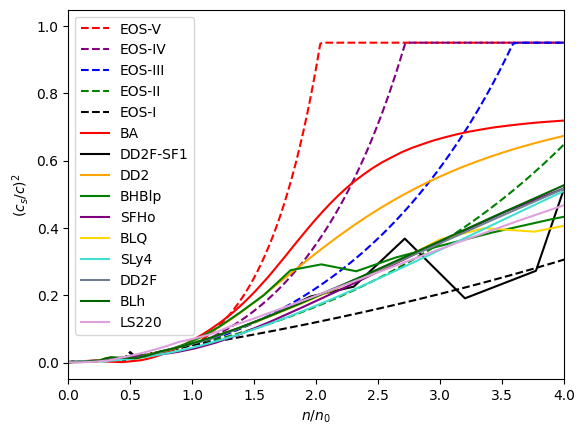

In [12]:
for name in RVSS_List.keys():
    eos_data = np.loadtxt(f'./Figure_Data/EOS/cs2/eos_{name}_cs2.txt')
    plt.plot(eos_data[:,0],eos_data[:,1],color=RVSS_List[name][1],linestyle='--',label=f'EOS-{name}')

for eos in eos_colors.keys():
    print(eos)
    eos_data = np.loadtxt(f'./Figure_Data/EOS/cs2/{eos}_cs2.txt')
    plt.plot(eos_data[:,0],eos_data[:,1],label=eos,color=eos_colors[eos])

plt.xlim([0,4])
plt.xlabel(r'$n/n_0$')
plt.ylabel(r'$(c_s/c)^2$')

plt.legend()



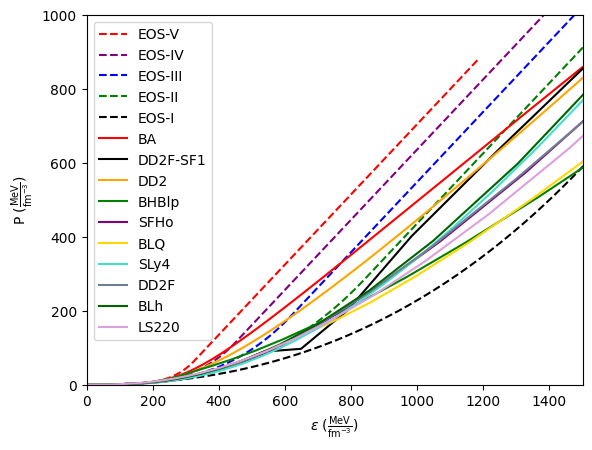

In [ ]:
for name in RVSS_List.keys():
    eos_data = np.loadtxt(f'./Figure_Data/EOS/p_vs_e/{name}_pve.txt')
    plt.plot(eos_data[:,0],eos_data[:,1],color=RVSS_List[name][1],linestyle='--',label=f'EOS-{name}')

for eos in eos_colors.keys():
    eos_data = np.loadtxt(f'./Figure_Data/EOS/p_vs_e/{eos}_pve.txt')
    plt.plot(eos_data[:,0],eos_data[:,1],label=eos,color=eos_colors[eos])


# plt.plot(RVSS_List["V"][0].E_unified,RVSS_List["V"][0].P_unified,color = RVSS_List["V"][1],linestyle='--',label="EOS-V")
# plt.plot(RVSS_List["IV"][0].E_unified,RVSS_List["IV"][0].P_unified,color = RVSS_List["IV"][1],linestyle='--',label="EOS-IV")
# plt.plot(RVSS_List["III"][0].E_unified,RVSS_List["III"][0].P_unified,color = RVSS_List["III"][1],linestyle='--',label="EOS-III")
# plt.plot(RVSS_List["II"][0].E_unified,RVSS_List["II"][0].P_unified,color = RVSS_List["II"][1],linestyle='--',label="EOS-II")
# plt.plot(RVSS_List["I"][0].E_unified,RVSS_List["I"][0].P_unified,color = RVSS_List["I"][1],linestyle='--',label="EOS-I")

# for eos in eos_eden:
#     plt.plot(eos_eden[eos],eos_press[eos],label=eos,color=eos_colors[eos])

plt.xlim([0,1500])
plt.ylim([0,1000])
plt.ylabel(r"$\text{P }(\frac{\text{MeV}}{\text{fm}^{-3}})$")
plt.xlabel(r"$\varepsilon \text{ }(\frac{\text{MeV}}{\text{fm}^{-3}})$")
plt.legend()


[[ 1.02373591e-01  2.00000000e+01  1.44973207e-01  3.43618463e-03
   4.80821876e-02  9.76981767e+02  2.58196562e-05  4.31568922e+00
   2.51005458e-02 -9.85099553e+05]
 [ 1.07275658e-01  2.00000000e+01  1.46996354e-01  3.37960589e-03
   5.03427225e-02  9.77648537e+02  2.71948860e-05  4.24393487e+00
   2.64475541e-02 -1.04894669e+06]
 [ 1.12604808e-01  2.00000000e+01  1.49051621e-01  3.32476207e-03
   5.27066367e-02  9.78349217e+02  2.86223926e-05  4.17619601e+00
   2.78469850e-02 -1.11623058e+06]
 [ 1.18376041e-01  2.00000000e+01  1.51141274e-01  3.28201982e-03
   5.50988440e-02  9.79084561e+02  3.01025006e-05  4.11264469e+00
   2.92993255e-02 -1.18526564e+06]
 [ 1.24604345e-01  1.98899924e+01  1.53267132e-01  3.23909583e-03
   5.76359530e-02  9.79857000e+02  3.16370936e-05  4.05064871e+00
   3.08066106e-02 -1.25614295e+06]
 [ 1.31305015e-01  1.86862227e+01  1.55433159e-01  3.22357271e-03
   6.02198492e-02  9.80667886e+02  3.32322229e-05  3.98976284e+00
   3.23749076e-02 -1.32779581e+06

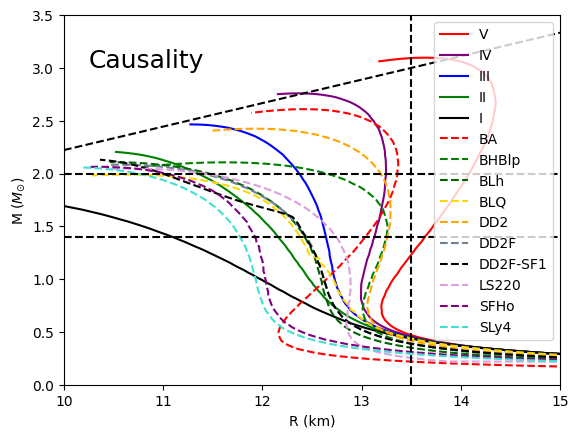

In [ ]:
r_causailty = np.linspace(10,15,100)
m_causality = r_causailty/4.5
for model in RVSS_List:
    MVR_data = np.loadtxt(f'./Figure_Data/EOS/MVR/{model}_mvr.txt')
    R = MVR_data[:,1]
    M = MVR_data[:,0]
    plt.plot(R,M,label=model,color=RVSS_List[model][1])
plt.plot(r_causailty,m_causality,linestyle='--',color = 'black')
for eos in eos_list:
    if eos == 'MS1b' or eos =='SLy':
        continue
    MVR_data = np.loadtxt(f'./Figure_Data/EOS/MVR/CORE/{eos}_MVR.txt')
    M = MVR_data[:,0]
    R = MVR_data[:,1]

    plt.plot(R,M,label=eos,color=eos_colors[eos],linestyle='--')
plt.legend()
plt.xlim([10,15])
plt.ylabel(r'$\text{M }(M_{\odot})$')
plt.xlabel(r'R (km)')
plt.ylim([0,3.5])
plt.text(10.25,3.0,"Causality",fontsize=18)
plt.axhline(y=2.0,linestyle='--',color = 'black')
plt.axhline(y=1.4,linestyle='--',color = 'black')
plt.axvline(x=13.5,linestyle='--',color='black')
plt.savefig('./Figures/Final_Paper_Figs/MVR_RVSS.pdf',format='pdf')
plt.show()




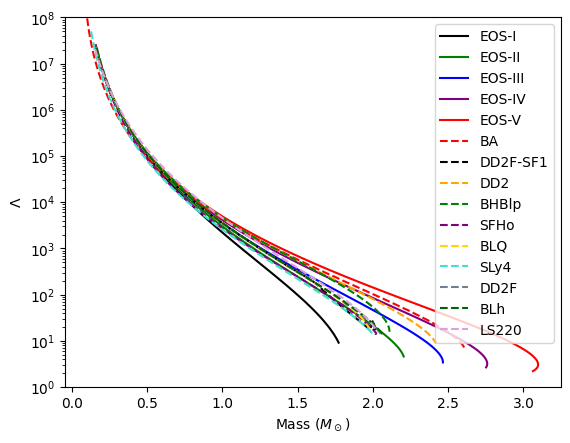

In [42]:
for name in ["I","II","III","IV","V"]:
    lambda_data = np.loadtxt(f'./Figure_Data/EOS/lambda/{name}_lambda.txt')
    plt.plot(lambda_data[:,0],lambda_data[:,1],color=RVSS_List[name][1],label=f"EOS-{name}")
for eos in eos_colors.keys():
    lambda_data = np.loadtxt(f'./Figure_Data/EOS/lambda/{eos}_lambda.txt')
    i_stop = 90
    plt.plot(lambda_data[:i_stop,0],lambda_data[:i_stop,1],color=eos_colors[eos],label=eos,linestyle='--')
plt.yscale('log')
plt.xlabel(r'$\text{Mass } (M_\odot)$')
plt.ylabel(r'$\Lambda$')
plt.ylim([1,100000000])
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/Lambda_M_Alpha.pdf',format='pdf')
plt.show()

In [20]:
eos_list = [file.split("_cs2prime")[0] for file in os.listdir('./Figure_Data/EOS/cs2primeEOS')]
print(eos_list)
RVSS_List = {}

eos_dens = {}
eos_cs2prime = {}

for eos_name in eos_list:
    eos_data = np.loadtxt(f'./Figure_Data/EOS/cs2primeEOS/{eos_name}_cs2prime_dens.txt')
    eos_dens[eos_name] = eos_data[:,0]
    eos_cs2prime[eos_name] = eos_data[:,1]

RVSS_List["V"] = (None,'red',3.899999999999999821*10**(-3))
RVSS_List["IV"] = (None,'purple',2.700000000000000143*10**(-3))
RVSS_List["III"] = (None,'blue', 2.099999999999999870*10**(-3))
RVSS_List["II"] = (None,'green',1.699999999999999895*10**(-3))
RVSS_List["I"] = (None,'black',1.199999999999999895*10**(-3))

['BA', 'BHBlp', 'BLh', 'BLQ', 'DD2F-SF1', 'DD2F', 'DD2', 'LS220', 'SFHo', 'SLy4']


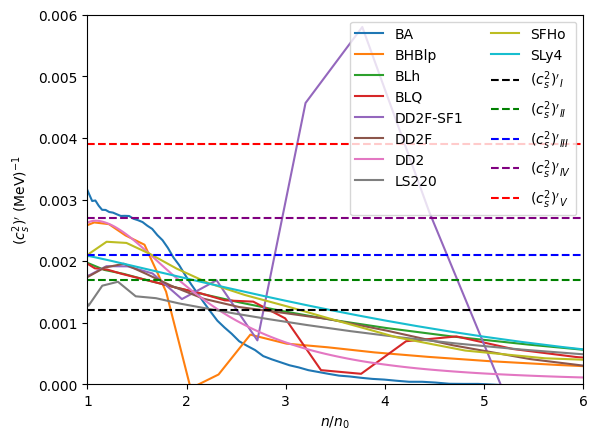

In [22]:
for eos_name in eos_list:
    plt.plot(eos_dens[eos_name],eos_cs2prime[eos_name],label=eos_name)
plt.axhline(RVSS_List["I"][2],color = RVSS_List["I"][1],linestyle='--',label=r"$(c_s^2)'_{I}$")
plt.axhline(RVSS_List["II"][2],color = RVSS_List["II"][1],linestyle='--',label=r"$(c_s^2)'_{II}$")
plt.axhline(RVSS_List["III"][2],color = RVSS_List["III"][1],linestyle='--',label=r"$(c_s^2)'_{III}$")
plt.axhline(RVSS_List["IV"][2],color = RVSS_List["IV"][1],linestyle='--',label=r"$(c_s^2)'_{IV}$")
plt.axhline(RVSS_List["V"][2],color = RVSS_List["V"][1],linestyle='--',label=r"$(c_s^2)'_{V}$")
plt.ylim([0,0.006])
plt.xlim([1,6])
plt.ylabel(r"$(c_s^2)' \text{ (MeV)}^{-1}$")
plt.xlabel(r"$n/n_0$")
plt.legend(ncol=2)